In [1]:


from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy import text, bindparam

from nhs_waiting_lists import (
    __app_name__,
)
from nhs_waiting_lists.constants import proj_db_path, DB_FILE
from nhs_waiting_lists.utils.xdg import XDGBasedir

project_root = Path(XDGBasedir.get_data_dir(__app_name__))

DB_PATH = project_root / proj_db_path / DB_FILE
FILES_DIR = project_root / "files"

engine = create_engine(f"sqlite:///{DB_PATH}")

In [2]:
# PROVIDER_CODES = ['R0B', 'RAJ', 'RTH', 'RTE', "RTF", "RWF", "RTE", "REF", "RWH", "R0B", "RVJ", "RHW", "RDU", "RH8",
#                   "RWY",
#                   "RXC", "RL4", "RDE", "RXK", "RXR", "RJ2", "RN5", "RHU", "RGN", "RWP", "RWD", "RAJ", 'RTF', 'RXC']
# # PROVIDER_COEDS = ('RAJ', 'RTH', 'RJZ', 'RH5', 'R0B', 'RTF', 'RXC')
# TREATMENT_CODES = (
#     'C_100',
#     'C_101',
#     'C_110',
#     'C_320',
#     'C_330',
#     'C_400',
#     'C_502',
#     'C_301'
# )

PROVIDER_CODES = ["RTF", "RWF", "RTE", "REF", "RWH", "R0B", "RVJ", "RHW", "RDU", "RH8", "RWY", "RXC", "RL4", "RDE",
                  "RXK", "RXR", "RJ2", "RN5", "RHU", "RGN", "RWP", "RWD", "RAJ"]
TREATMENT_CODES = ('C_101', 'C_110', 'C_320', 'C_330', 'C_400', 'C_502', 'C_301', 'C_100', 'C_101', 'C_110', 'C_120',
                   'C_130', 'C_140', 'C_150', 'C_160', 'C_170', 'C_300', 'C_301', 'C_320', 'C_330', 'C_340', 'C_400',
                   'C_410', 'C_430', 'C_502')

# TREATMENT_CODES = ('C_999',)

provider_code = "RAJ"
treatment_code = "C_110"

In [3]:
consolidated_query = text("""
                          SELECT period,
                                 provider,
                                 treatment,
                                 i.incomplete_prev,
                                 i.incomplete - i.incomplete_prev                 AS inc_diff,
                                 (
                                     (i.incomplete / NULLIF(i.incomplete_prev, 0)
                                         ) - 1)                                   AS frac_change,
                                 -- the accounting identity
                                 (
                                     i.incomplete
                                         - (i.incomplete_prev
                                                + i.new_periods
                                         - i.nonadmitted
                                         - i.admitted
                                         ))                                       AS residual,
                                 -- scaled accounting identity
                                 (
                                     i.incomplete
                                         - (i.incomplete_prev
                                                + i.new_periods
                                         - i.nonadmitted
                                         - i.admitted
                                         )) / (i.incomplete_prev + i.new_periods) AS r,
                                 i.admitted,
                                 i.nonadmitted,
                                 i.new_periods,
                                 i.incomplete
                          FROM consolidated AS i
                          WHERE provider IN :provider_codes
                            AND treatment IN :treatment_codes
                            AND period >= '2024-08-01'
                          ORDER BY provider ASC, period ASC; \
                          """).bindparams(
    bindparam('provider_codes', expanding=True),
    bindparam('treatment_codes', expanding=True)
)

consolidated_df = pd.read_sql(consolidated_query, engine, params={
    'provider_codes': PROVIDER_CODES,
    'treatment_codes': TREATMENT_CODES}
                              )  # type: ignore[arg-type]

consolidated_df["period"] = pd.to_datetime(consolidated_df["period"], errors="coerce")

valid = (consolidated_df['incomplete_prev'] > 100) & (consolidated_df['new_periods'] > 30)
consolidated_df = consolidated_df.loc[valid].copy()
consolidated_df

,period,provider,treatment,incomplete_prev,inc_diff,frac_change,residual,r,admitted,nonadmitted,new_periods,incomplete
0,2024-09-01,R0B,C_100,4901.0,1.0,0.0,-82.0,0.0,686,958,1727,4902
1,2024-09-01,R0B,C_101,5938.0,71.0,0.0,-194.0,0.0,360,934,1559,6009
2,2024-09-01,R0B,C_110,8732.0,-134.0,-1.0,-106.0,0.0,335,1228,1535,8598
3,2024-09-01,R0B,C_120,4504.0,-153.0,-1.0,-156.0,0.0,197,1072,1272,4351
4,2024-09-01,R0B,C_130,8841.0,-92.0,-1.0,-306.0,0.0,978,1312,2504,8749
...,...,...,...,...,...,...,...,...,...,...,...,...
4576,2025-09-01,RXR,C_320,3600.0,-184.0,-1.0,-183.0,0.0,60,508,567,3416
4577,2025-09-01,RXR,C_330,2671.0,113.0,0.0,23.0,0.0,1,450,541,2784
4578,2025-09-01,RXR,C_340,798.0,-78.0,-1.0,-73.0,0.0,10,344,349,720
4579,2025-09-01,RXR,C_410,929.0,16.0,0.0,-2.0,0.0,8,174,200,945


In [4]:
import numpy as np

# After loading the dataframe
consolidated_df['r_peer_median'] = consolidated_df.groupby(
    ['period', 'treatment']
)['r'].transform('median')

consolidated_df['r_peer_mean'] = consolidated_df.groupby(
    ['period', 'treatment']
)['r'].transform('mean')

consolidated_df['r_peer_std'] = consolidated_df.groupby(
    ['period', 'treatment']
)['r'].transform('std')

group = consolidated_df.groupby(['period', 'treatment'])
consolidated_df['r_mad'] = group['r'].transform(lambda x: 1.4826 * (x - x.median()).abs().median())
consolidated_df['r_z'] = (consolidated_df['r'] - consolidated_df['r_peer_median']) / consolidated_df['r_mad']

consolidated_df['excess_flag'] = (consolidated_df['r_z'] < -2).astype(int)
consolidated_df['cum_excess'] = consolidated_df.groupby(['provider', 'treatment'])['excess_flag'].cumsum()

consolidated_df['denom'] = consolidated_df['incomplete_prev'] + consolidated_df['new_periods']
consolidated_df['r_low'] = consolidated_df['r_peer_median'] - 2 * consolidated_df['r_mad']
consolidated_df['expected_min_resid'] = consolidated_df['r_low'] * consolidated_df['denom']

# Missing patients this month (beyond expected min)
consolidated_df['excess_missing'] = np.where(consolidated_df['residual'] < consolidated_df['expected_min_resid'],
                                             consolidated_df['expected_min_resid'] - consolidated_df['residual'],
                                             0)

consolidated_df

,period,provider,treatment,incomplete_prev,inc_diff,frac_change,residual,r,admitted,nonadmitted,...,r_peer_mean,r_peer_std,r_mad,r_z,excess_flag,cum_excess,denom,r_low,expected_min_resid,excess_missing
0,2024-09-01,R0B,C_100,4901.0,1.0,0.0,-82.0,0.0,686,958,...,0.0,0.0,0.0,NaN,0,0,6628.0,0.0,0.0,82.0
1,2024-09-01,R0B,C_101,5938.0,71.0,0.0,-194.0,0.0,360,934,...,0.0,0.0,0.0,NaN,0,0,7497.0,0.0,0.0,194.0
2,2024-09-01,R0B,C_110,8732.0,-134.0,-1.0,-106.0,0.0,335,1228,...,0.0,0.0,0.0,NaN,0,0,10267.0,0.0,0.0,106.0
3,2024-09-01,R0B,C_120,4504.0,-153.0,-1.0,-156.0,0.0,197,1072,...,0.0,0.0,0.0,NaN,0,0,5776.0,0.0,0.0,156.0
4,2024-09-01,R0B,C_130,8841.0,-92.0,-1.0,-306.0,0.0,978,1312,...,0.0,0.0,0.0,NaN,0,0,11345.0,0.0,0.0,306.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4576,2025-09-01,RXR,C_320,3600.0,-184.0,-1.0,-183.0,0.0,60,508,...,0.0,0.0,0.0,NaN,0,0,4167.0,0.0,0.0,183.0
4577,2025-09-01,RXR,C_330,2671.0,113.0,0.0,23.0,0.0,1,450,...,0.0,0.0,0.0,NaN,0,0,3212.0,0.0,0.0,0.0
4578,2025-09-01,RXR,C_340,798.0,-78.0,-1.0,-73.0,0.0,10,344,...,0.0,0.0,0.0,NaN,0,0,1147.0,0.0,0.0,73.0
4579,2025-09-01,RXR,C_410,929.0,16.0,0.0,-2.0,0.0,8,174,...,0.0,0.0,0.0,NaN,0,0,1129.0,0.0,0.0,2.0


In [5]:
df_xs = consolidated_df.query("excess_missing > 0")

print(df_xs["excess_missing"].sum())

consolidated_df.query("provider == 'RXR' and treatment == 'C_110' and period == '2024-10'")[[
    'incomplete_prev', 'incomplete', 'new_periods', 'admitted', 'nonadmitted', 'residual', 'excess_missing'
]]


703711.0


/tmp/ipykernel_1603747/243551068.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  consolidated_df.query("provider == 'RXR' and treatment == 'C_110' and period == '2024-10'")[[


,incomplete_prev,incomplete,new_periods,admitted,nonadmitted,residual,excess_missing
4417,7948.0,7377,1199,344,408,-1018.0,1018.0


In [6]:
provider_treatment_rank = (
    consolidated_df
    .groupby(['provider', 'treatment'], as_index=False)['excess_missing']
    .sum()
    .rename(columns={'excess_missing': 'total_excess_missing'})
)

# rank within treatment, or overall
provider_treatment_rank['rank_within_treatment'] = (
    provider_treatment_rank.groupby('treatment')['total_excess_missing']
    .rank(ascending=False, method='min')
)
provider_treatment_rank['rank_overall'] = provider_treatment_rank['total_excess_missing'] \
    .rank(ascending=False, method='min')

provider_treatment_rank = provider_treatment_rank.sort_values('total_excess_missing', ascending=False)

provider_treatment_rank.head(10)

,provider,treatment,total_excess_missing,rank_within_treatment,rank_overall
15,RAJ,C_110,18000.0,1.0,1.0
181,RTE,C_320,15904.0,1.0,2.0
21,RAJ,C_301,15649.0,1.0,3.0
17,RAJ,C_130,14909.0,1.0,4.0
22,RAJ,C_320,12724.0,2.0,5.0
28,RAJ,C_502,11563.0,1.0,6.0
188,RTF,C_100,11073.0,1.0,7.0
122,RHW,C_130,10969.0,2.0,8.0
14,RAJ,C_101,10894.0,1.0,9.0
180,RTE,C_301,10263.0,2.0,10.0


In [7]:
provider_rank = (
    consolidated_df
    .groupby(['provider'], as_index=False)['excess_missing']
    .sum()
    .rename(columns={'excess_missing': 'total_excess_missing'})
)
provider_rank = provider_rank.sort_values('total_excess_missing', ascending=False)

provider_rank.head(10)

,provider,total_excess_missing
1,RAJ,122938.0
8,RHW,66206.0
12,RTE,65972.0
9,RJ2,41085.0
2,RDE,39815.0
13,RTF,34315.0
22,RXR,31774.0
21,RXK,27782.0
10,RL4,24991.0
17,RWH,24689.0


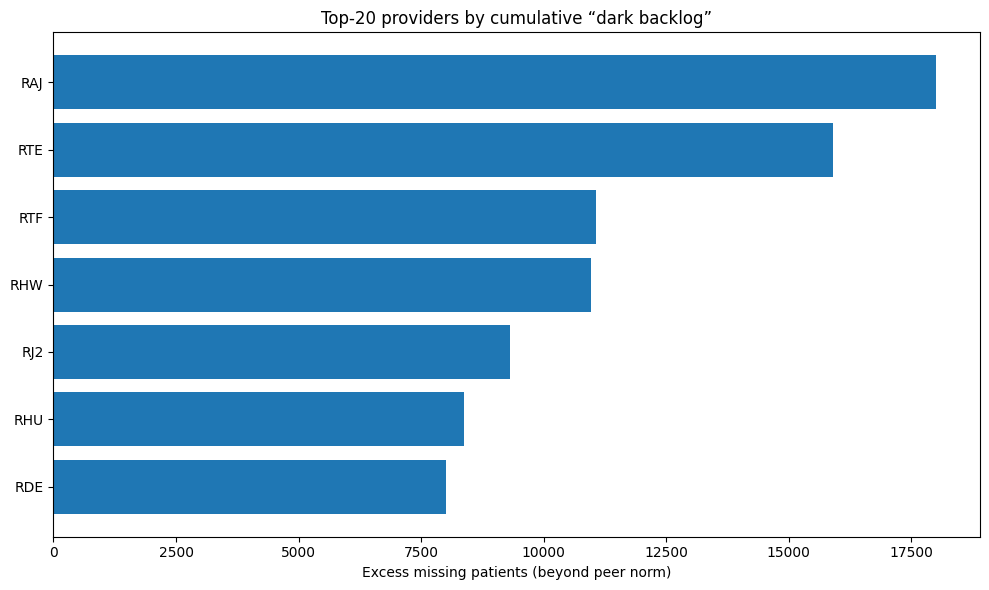

In [8]:
import matplotlib.pyplot as plt

top20 = provider_treatment_rank.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top20['provider'], top20['total_excess_missing'])
plt.gca().invert_yaxis()
plt.xlabel('Excess missing patients (beyond peer norm)')
plt.title('Top-20 providers by cumulative “dark backlog”')
plt.tight_layout()
plt.show()

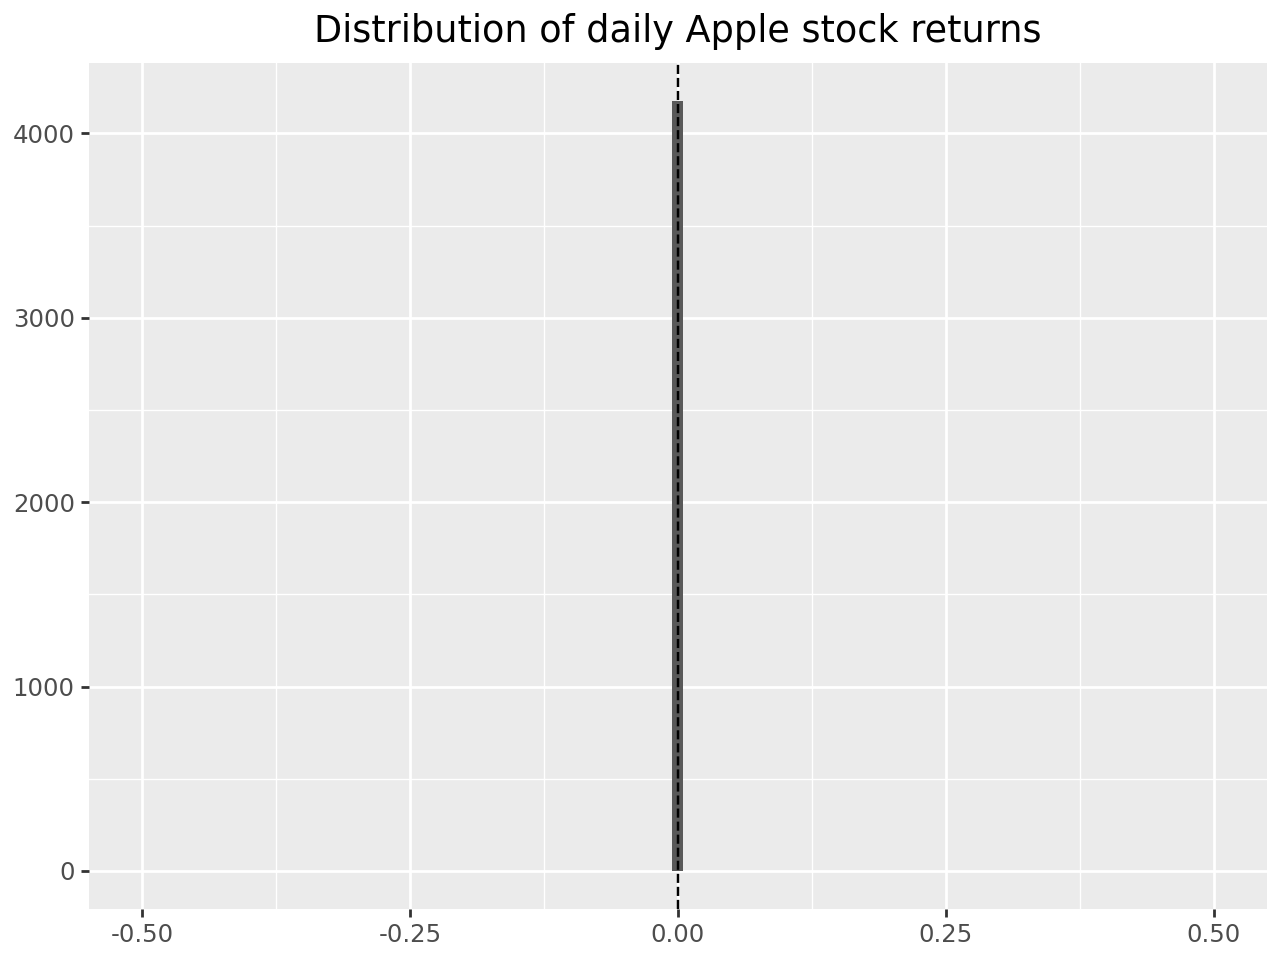

In [9]:

from plotnine import (
    ggplot, aes, geom_histogram, geom_vline, labs
)

quantile_05 = consolidated_df["r_peer_median"].quantile(0.05)

apple_returns_figure = (
        ggplot(consolidated_df, aes(x="r_peer_median"))
        + geom_histogram(bins=100)
        + geom_vline(aes(xintercept=quantile_05), linetype="dashed")
        + labs(x="", y="", title="Distribution of daily Apple stock returns")

)
apple_returns_figure.show()

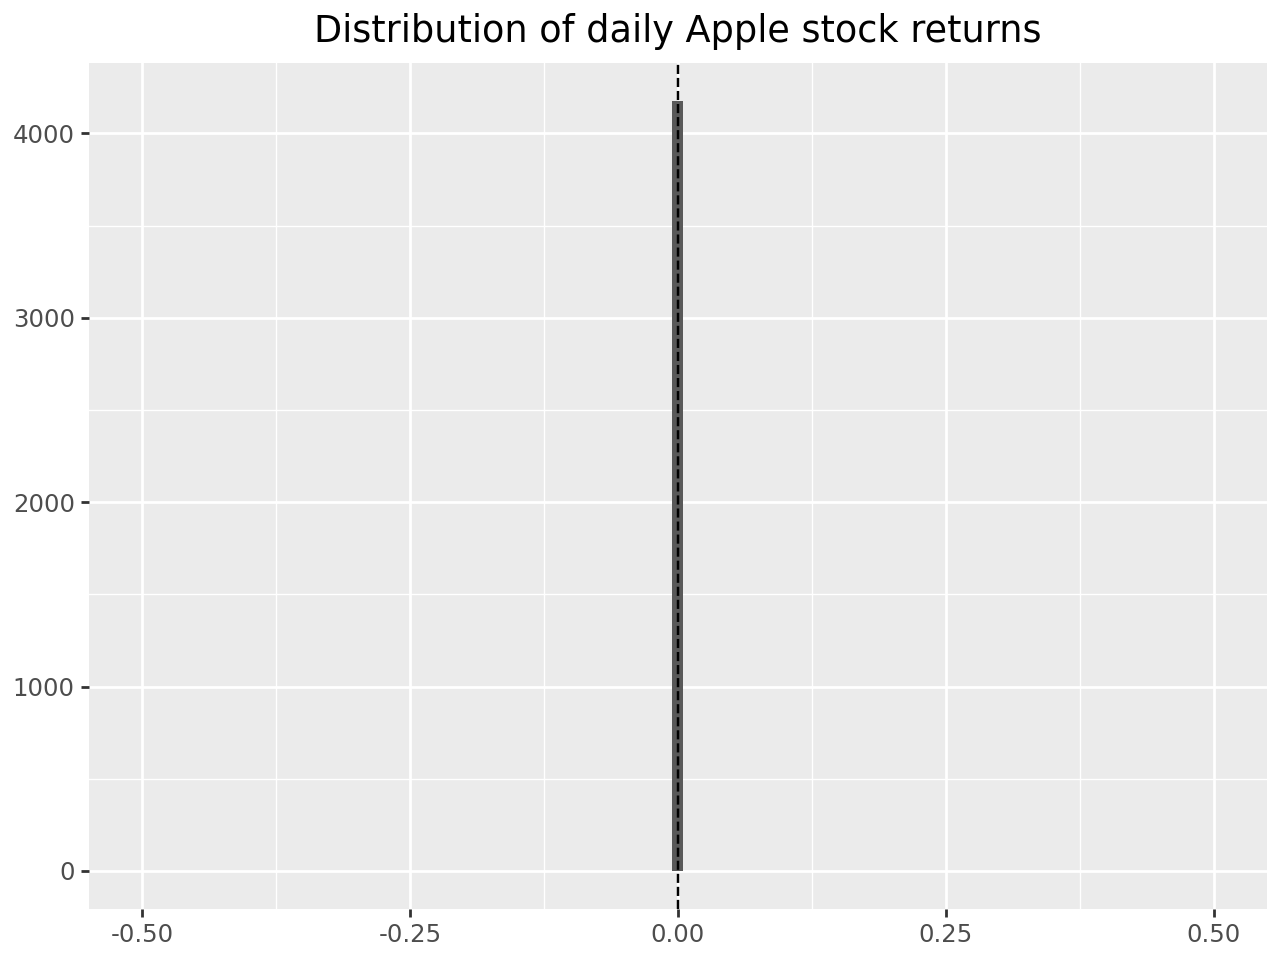

In [10]:

from plotnine import (
    ggplot, aes, geom_histogram, geom_vline, labs
)

quantile_05 = consolidated_df["r"].quantile(0.05)

apple_returns_figure = (
        ggplot(consolidated_df, aes(x="r"))
        + geom_histogram(bins=100)
        + geom_vline(aes(xintercept=quantile_05), linetype="dashed")
        + labs(x="", y="", title="Distribution of daily Apple stock returns")

)
apple_returns_figure.show()

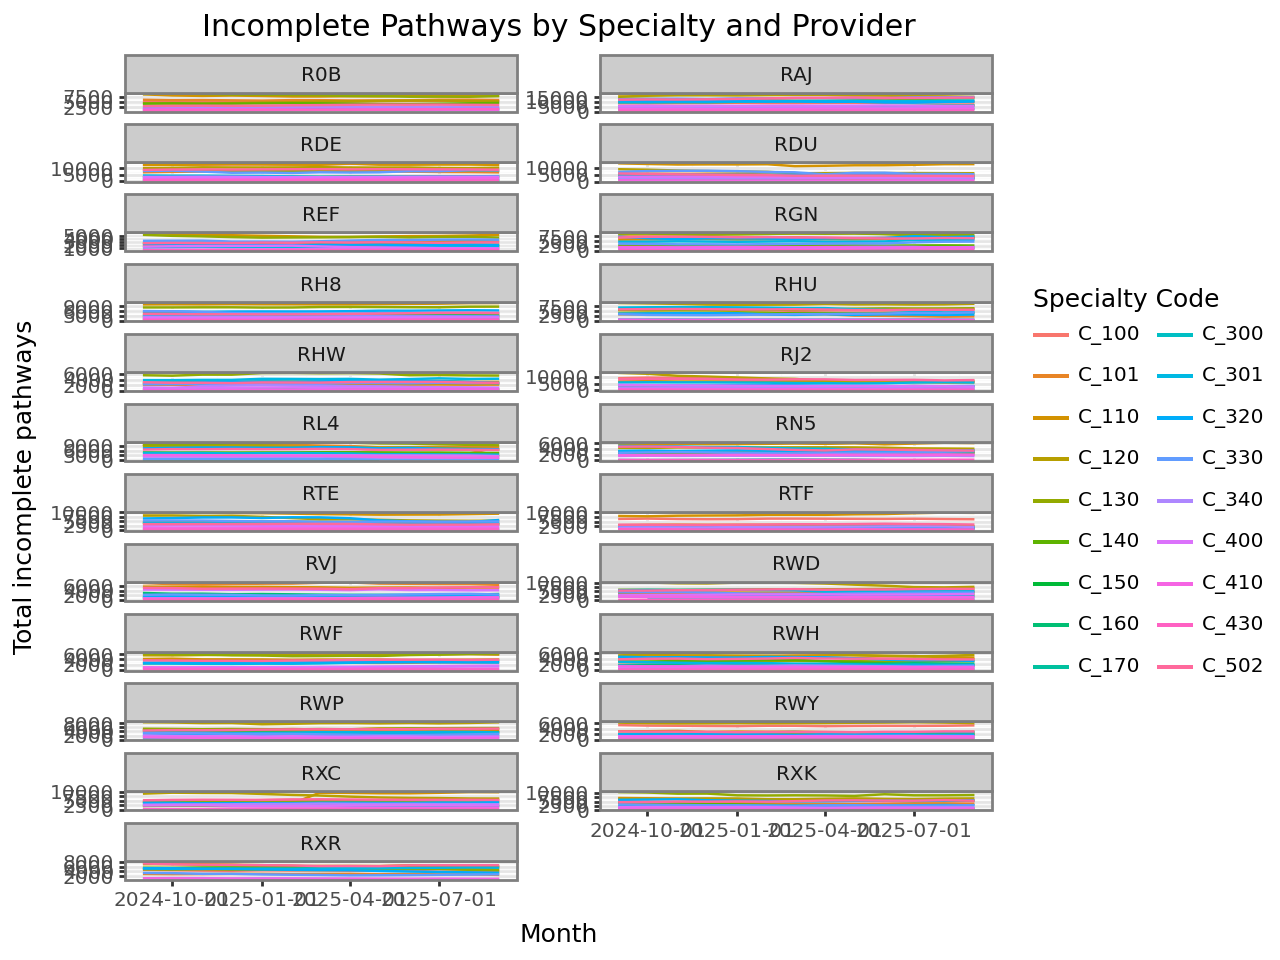

In [11]:
from plotnine import (
    theme_minimal,
    scale_x_datetime
)
from plotnine import ggplot, aes, geom_line, facet_wrap, labs, theme_bw

p7 = (
        ggplot(consolidated_df, aes(x="period", y="incomplete", color="treatment", group="treatment"))
        + geom_line()
        + facet_wrap("~provider", ncol=2, scales="free_y")  # one plot per provider
        + labs(
    title="Incomplete Pathways by Specialty and Provider",
    x="Month",
    y="Total incomplete pathways",
    color="Specialty Code"
)
        + theme_bw(base_size=9)
)
p7

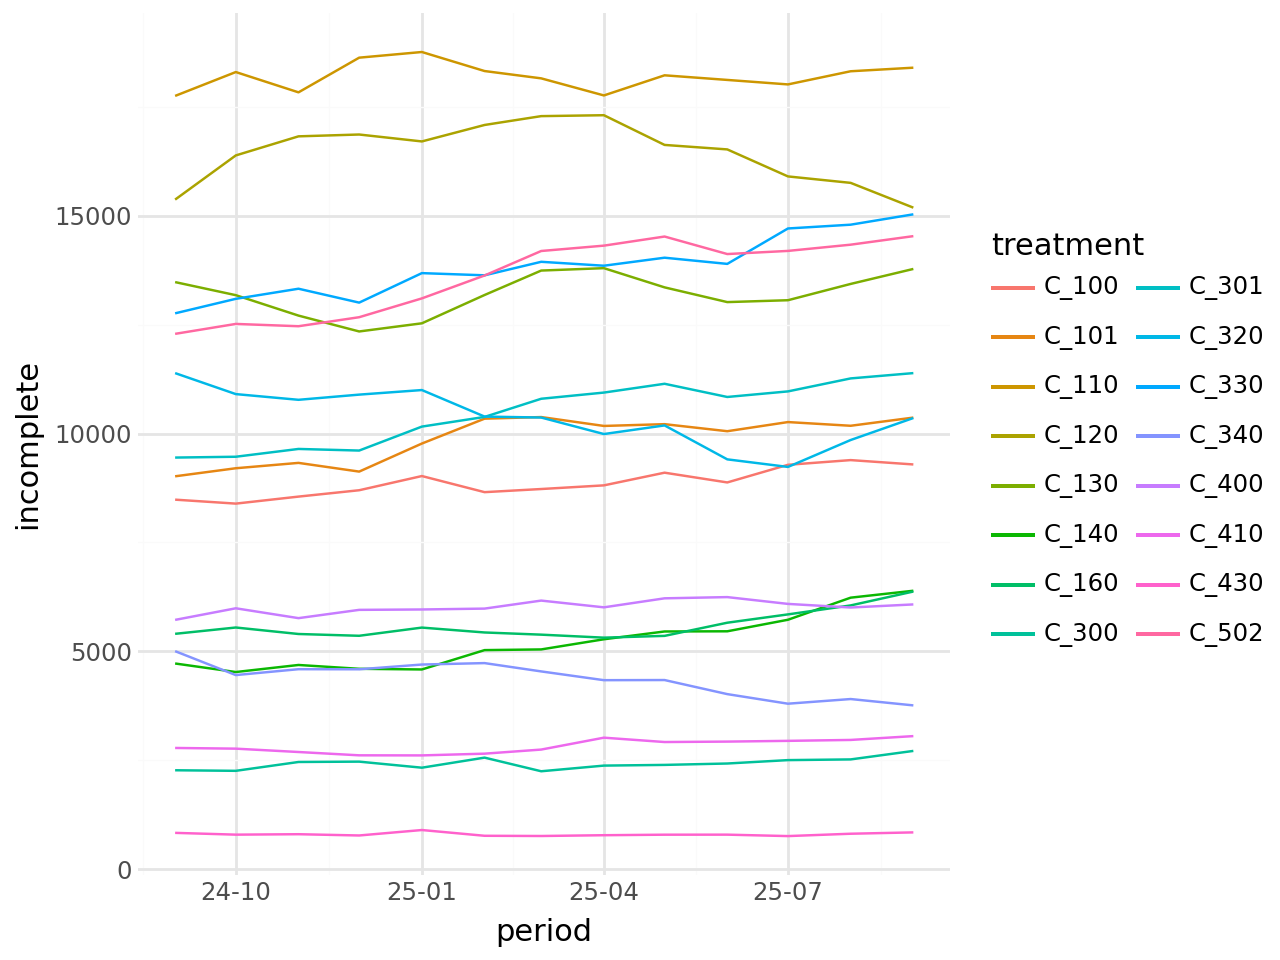

In [12]:
p = (
        ggplot(consolidated_df.query(f"provider == '{provider_code}'"),
               aes(x="period", y="incomplete", color="treatment", group="treatment"))
        + geom_line()
        + theme_minimal()
        + scale_x_datetime(date_labels="%y-%m")
)
p

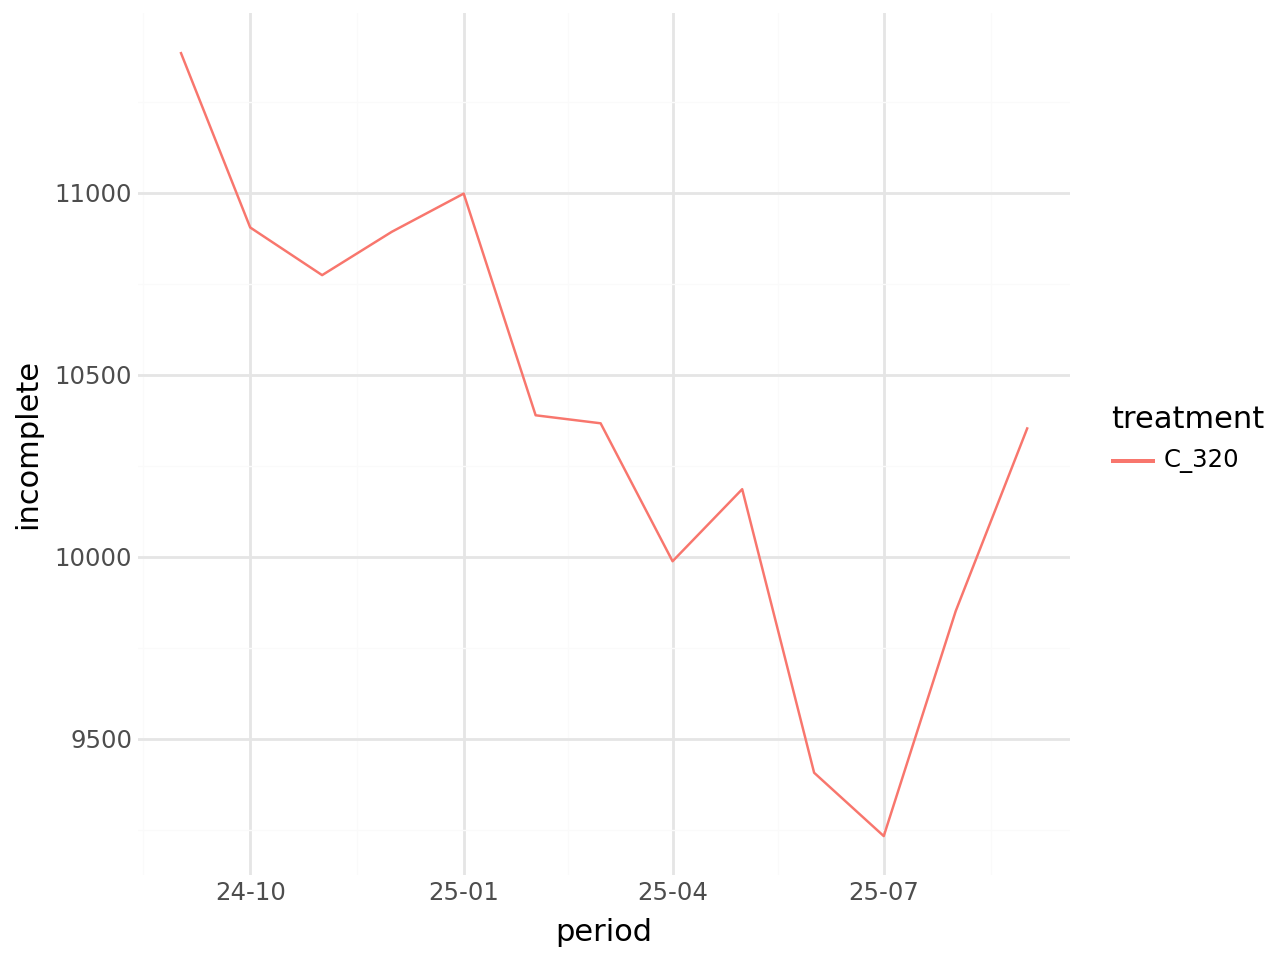

In [13]:
p2 = (
        ggplot(consolidated_df.query(f"provider == '{provider_code}'").query("treatment == 'C_320'"),
               aes(x="period", y="incomplete", color="treatment", group="treatment"))
        + geom_line()
        + theme_minimal()
        + scale_x_datetime(date_labels="%y-%m")
)
p2

In [14]:

import statsmodels.api as sm

df = consolidated_df.query(f"provider == '{provider_code}'").query("treatment == 'C_320'")
X = sm.add_constant(df['r_peer_median'])
y = df['r']
ols = sm.OLS(y, X).fit(cov_type='HC3')
print(ols.params, ols.rsquared)
print(ols.summary2())

const            0.0
r_peer_median    0.0
dtype: float64 nan
                Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     nan   
Dependent Variable: r                AIC:                -inf  
Date:               2025-12-07 08:58 BIC:                -inf  
No. Observations:   13               Log-Likelihood:     inf   
Df Model:           0                F-statistic:        nan   
Df Residuals:       12               Prob (F-statistic): nan   
R-squared:          nan              Scale:              0.0000
-----------------------------------------------------------------
                Coef.    Std.Err.    z    P>|z|   [0.025   0.975]
-----------------------------------------------------------------
const           0.0000     0.0000   nan     nan   0.0000   0.0000
r_peer_median   0.0000     0.0000   nan     nan   0.0000   0.0000
---------------------------------------------------------------
Omnibus:                nan        Durbin-Watson:

/home/tomhodder/Sync/projects/data/nhs_england_data/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
/home/tomhodder/Sync/projects/data/nhs_england_data/.venv/lib/python3.13/site-packages/statsmodels/stats/stattools.py:50: RuntimeWarning: invalid value encountered in scalar divide
/home/tomhodder/Sync/projects/data/nhs_england_data/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
/home/tomhodder/Sync/projects/data/nhs_england_data/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
/home/tomhodder/Sync/projects/data/nhs_england_data/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
/home/tomhodder/Sync/proj

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# # Convert to datetime if not already
# subset_c_400 = consolidated_df[(consolidated_df["provider"] == "RAJ") & (consolidated_df["treatment"] == "C_400")].copy()
# subset_c_400["period"] = pd.to_datetime(subset_c_400["period"], errors="coerce")

consolidated_df = consolidated_df.reset_index()

returns_wide = (
    consolidated_df[(consolidated_df["provider"] == provider_code)].query(
        'treatment == "C_400" or treatment=="C_320"')
    .pivot(
        index="period",
        columns="treatment",
        values="residual"
    )
    .reset_index()
)
returns_wide

treatment,period,C_320,C_400
0,2024-09-01,-891.0,147.0
1,2024-10-01,-1162.0,-203.0
2,2024-11-01,-990.0,-533.0
3,2024-12-01,-832.0,-151.0
4,2025-01-01,-705.0,-275.0
5,2025-02-01,-1673.0,-185.0
6,2025-03-01,-947.0,-72.0
7,2025-04-01,-986.0,-180.0
8,2025-05-01,-827.0,-63.0
9,2025-06-01,-1881.0,-478.0


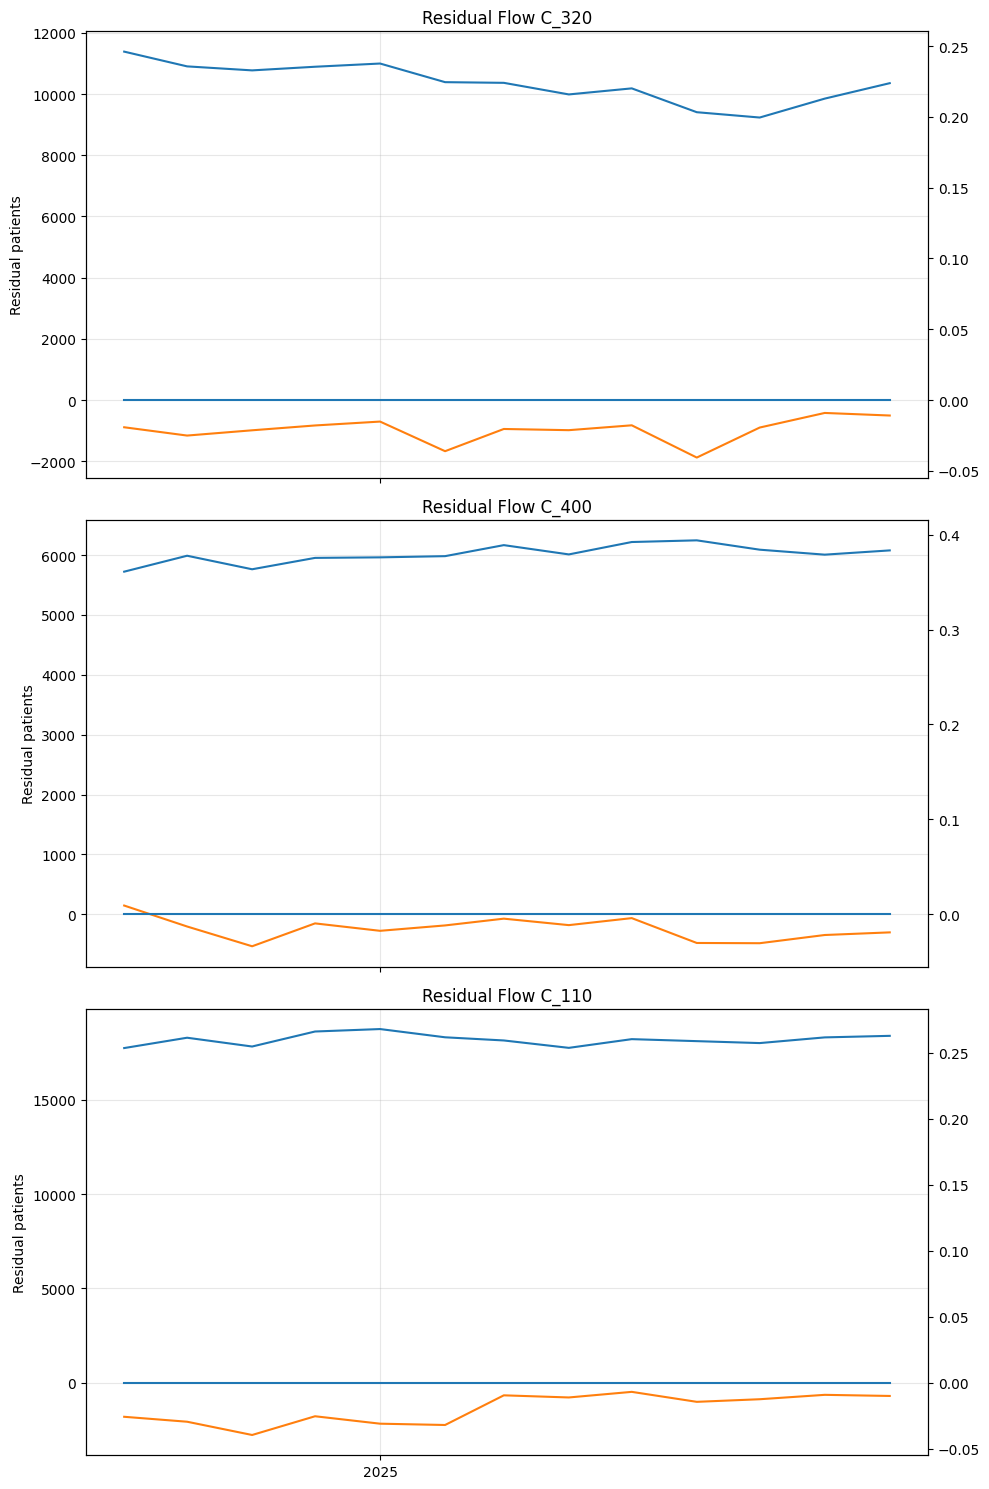

In [16]:


# Plot
fig, ax = plt.subplots(
    figsize=(10, 15),
    sharex=True,
    sharey=False,
    nrows=3,
    ncols=1,
)
returns_wide["period"] = pd.to_datetime(returns_wide["period"], errors="coerce")


# subset_c_400 = df[(df["provider"] == "RAJ") & (df["treatment"] == "C_400")].copy()
# subset_c_400["period"] = pd.to_datetime(subset_c_400["period"], errors="coerce")

def align_yaxis_zero(ax1, ax2):
    """Align the zero points of two y-axes."""
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    # Calculate the ratio of positive to negative range for ax1
    if y1_min < 0 < y1_max:
        ratio1 = y1_max / abs(y1_min)
    else:
        return  # Don't adjust if ax1 doesn't cross zero

    # Apply same ratio to ax2 if it crosses zero
    if y2_min < 0 < y2_max:
        # Adjust limits to match ratio
        new_y2_max = abs(y2_min) * ratio1
        ax2.set_ylim(y2_min, new_y2_max)


for ax_idx, colname in ([0, "C_320"], [1, "C_400"], [2, "C_110"]):
    ax[ax_idx].grid(True, alpha=0.3)

    subset = consolidated_df.query(f"provider == '{provider_code}' and treatment == @colname")

    ax[ax_idx].plot(subset["period"], subset["incomplete"], lw=1.5)
    ax[ax_idx].set_title(f"Residual Flow {colname}")
    ax[ax_idx].set_ylabel("Residual patients")
    ax[ax_idx].grid(True, alpha=0.3)
    ax[ax_idx].fill_between(subset["period"], subset["r"], where=subset["r"] < 0, facecolor='green', alpha=.5)
    ax[ax_idx].plot(subset["period"], subset["residual"], lw=1.5)

    ax2 = ax[ax_idx].twinx()
    ax2.plot(subset["period"], subset["r"], lw=1.5)
    ax2.fill_between(subset["period"], subset["r"], where=subset["r"] < 0, facecolor='green', alpha=.5)
    align_yaxis_zero(ax[ax_idx], ax2)

    # Yearly major ticks
    ax[ax_idx].xaxis.set_major_locator(mdates.YearLocator())
    ax[ax_idx].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # # Optional: quarterly minor ticks
    # ax[0].xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    # ax[0].xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

    plt.setp(ax[ax_idx].get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()


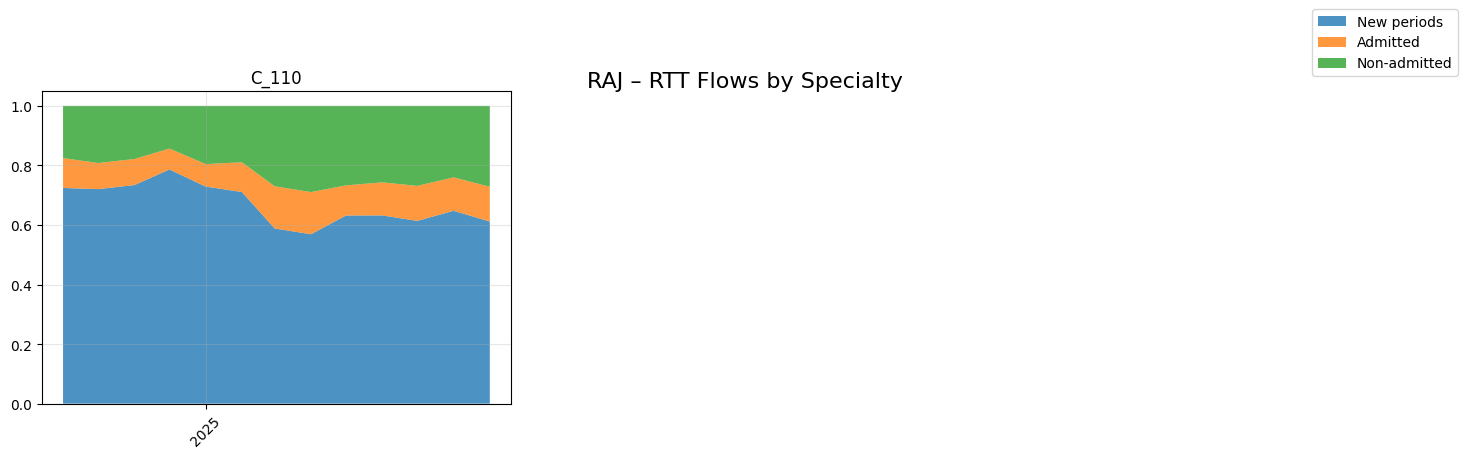

In [17]:

treatments = subset["treatment"].unique()
ncols = 3
nrows = -(-len(treatments) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True)
axes = axes.flatten()

for ax, tcode in zip(axes, treatments):
    d = subset[subset["treatment"] == tcode]
    d = d.sort_values("period")

    ax.xaxis.set_major_locator(mdates.YearLocator())  # one tick per year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis="x", rotation=0)

    d_norm = d[["admitted", "nonadmitted", "new_periods"]].div(
        d[["admitted", "nonadmitted", "new_periods"]].sum(axis=1), axis=0)

    ax.stackplot(
        d["period"],
        d_norm["new_periods"],
        d_norm["admitted"],
        d_norm["nonadmitted"],
        # labels=["new_periods", "Admitted", "Non-admitted"],
        alpha=0.8,
    )
    ax.set_title(tcode)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

# tidy up
for ax in axes[len(treatments):]:
    ax.set_visible(False)

fig.suptitle("RAJ – RTT Flows by Specialty", fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.93)

# one global legend
fig.legend(["New periods", "Admitted", "Non-admitted"],
           loc="lower right", bbox_to_anchor=(0.98, 0.95))

plt.show()
